# NetworkX Spatial Analysis
Dataset-agnostic workflow for visualizing and identifying critical WAPs.

In [6]:
import sys, os
from pathlib import Path
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from pipeline.run_logic.ast_runner import load_step_module
phase_dir = Path(project_root) / "pipeline" / "phases" / "phase_01_build_world--Lucas_Starkey"
load_step_module(phase_dir, phase_dir / "steps" / "step_01_build_devices.py")
load_step_module(phase_dir, phase_dir / "steps" / "step_04_build_graph.py")
load_step_module(phase_dir, phase_dir / "steps" / "step_05_build_journeys.py")
load_step_module(phase_dir, phase_dir / "steps" / "step_06_interpolate_paths.py")

from pipelineio.state import load_draft

run_id = os.environ.get('PIPELINE_RUN_ID', 'EXAMPLE_RUN_ID')
graph = load_draft(f'../data/artifacts/runs/{run_id}/world/final_graph.pkl')
journeys_data = load_draft(f'../data/artifacts/runs/{run_id}/world/final_journeys.pkl')


## Parse Graph into NetworkX DiGraph
Extracts traces and builds a directed graph weighting edges by traffic.

In [7]:
G = nx.DiGraph()

# Add all physical nodes first
for wap_id in graph.nodes.keys():
    G.add_node(wap_id, unique_visitors=graph.node_counts.get(wap_id, 0))

from datetime import datetime

# Iterate through all journeys to build exact temporal edges
for journey in journeys_data.journeys:
    for i in range(len(journey.waypoints) - 1):
        wp = journey.waypoints[i]
        next_wp = journey.waypoints[i+1]
        
        origin_wap = wp.wap_id
        dest_wap = next_wp.wap_id
        
        if origin_wap == dest_wap:
            continue

        dt = datetime.fromtimestamp(wp.timestamp / 1000.0)
        weekday = dt.weekday()
        
        if not G.has_node(origin_wap):
            G.add_node(origin_wap, unique_visitors=graph.node_counts.get(origin_wap, 0))
        if not G.has_node(dest_wap):
            G.add_node(dest_wap, unique_visitors=graph.node_counts.get(dest_wap, 0))
                
        if G.has_edge(origin_wap, dest_wap):
            G[origin_wap][dest_wap]['weight'] += 1
            G[origin_wap][dest_wap]['weekdays'][weekday] = G[origin_wap][dest_wap]['weekdays'].get(weekday, 0) + 1
        else:
            G.add_edge(origin_wap, dest_wap, weight=1, weekdays={weekday: 1})

print(f"Number of Nodes: {G.number_of_nodes()}")
print(f"Number of Edges: {G.number_of_edges()}")
print("\nSample Edges:")
print(list(G.edges(data=True))[:2])


Number of Nodes: 25
Number of Edges: 127

Sample Edges:
[('AIEB-RM253', 'AIEB-RMC138', {'weight': 1529, 'weekdays': {0: 314, 3: 270, 4: 254, 5: 18, 6: 40, 2: 321, 1: 312}}), ('AIEB-RM253', 'AIEB-RM261', {'weight': 935, 'weekdays': {3: 160, 1: 199, 6: 49, 2: 192, 4: 154, 0: 171, 5: 10}})]


## Draw the Network
Using a force-directed layout and mapping properties (Size=Degree, Width=Weight).

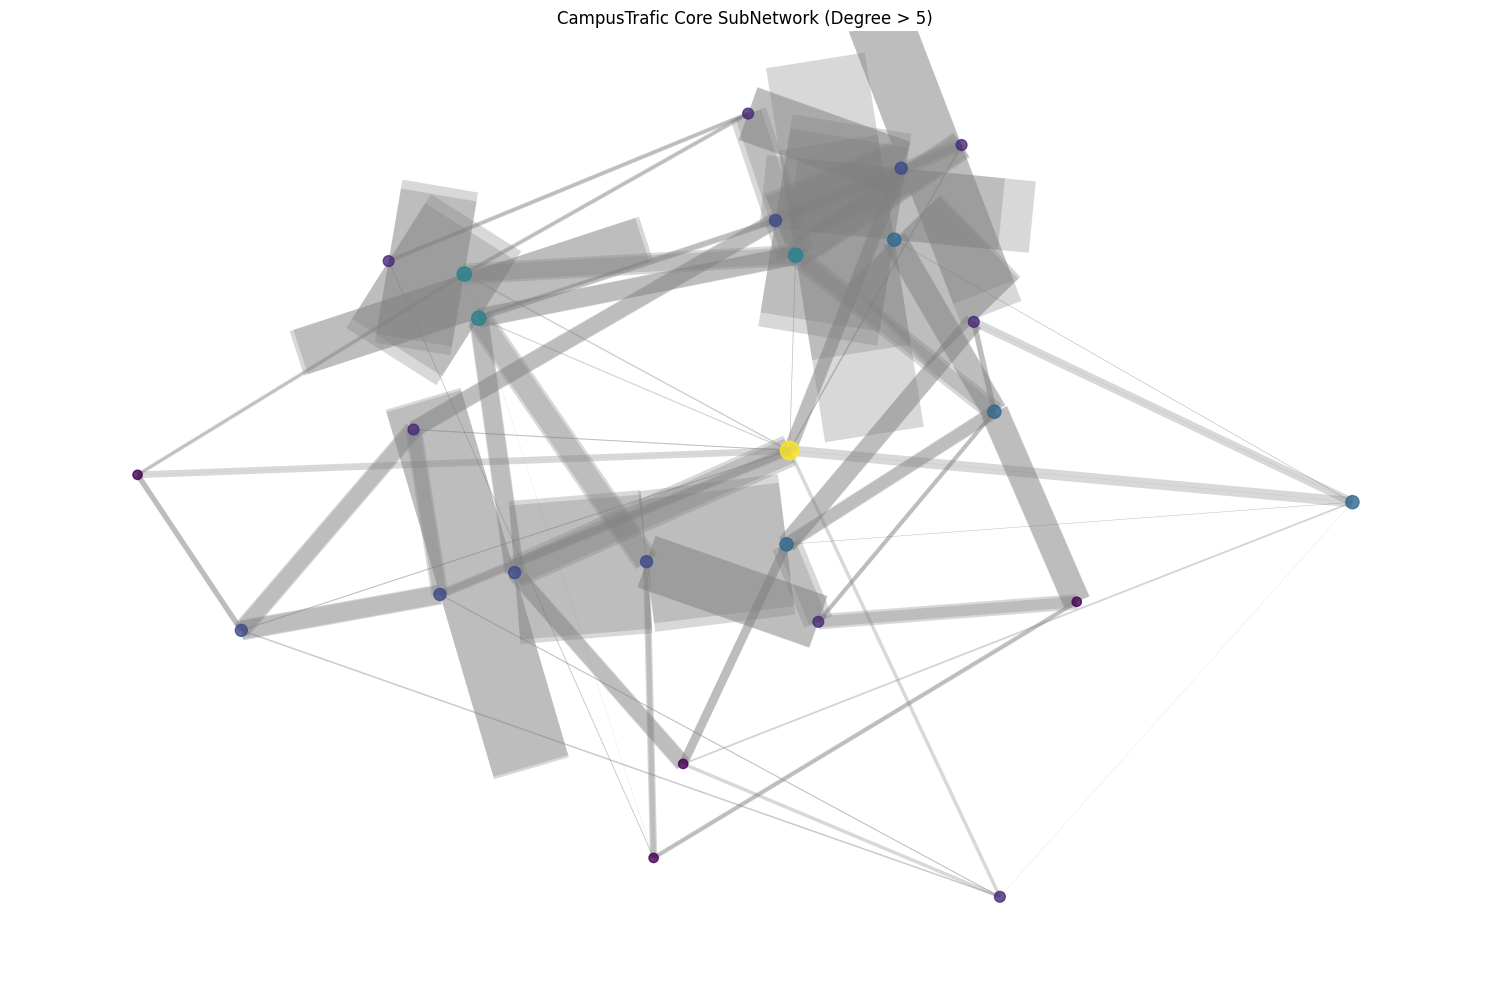

In [8]:
# Filter out weak nodes for readability
core_nodes = [n for n, d in G.degree() if d > 5]
sub_G = G.subgraph(core_nodes)

# Compute Spring Layout with fixed seed for reproducibility
pos = nx.spring_layout(sub_G, seed=42)

# Size & Color (based on In-degree importance measure)
in_degrees = dict(sub_G.in_degree())
node_sizes = [v * 15 for v in in_degrees.values()]
node_colors = list(in_degrees.values())

# Edge Widths (based on transition frequency weight)
edge_widths = [d['weight'] * 0.1 for u, v, d in sub_G.edges(data=True)]

plt.figure(figsize=(15, 10))
nx.draw_networkx_nodes(sub_G, pos, node_size=node_sizes, node_color=node_colors, cmap="viridis", alpha=0.8)
nx.draw_networkx_edges(sub_G, pos, width=edge_widths, edge_color="gray", alpha=0.3, arrows=False)

plt.title("CampusTrafic Core SubNetwork (Degree > 5)")
plt.axis("off") # Turn off axes for dense graph
plt.tight_layout()
plt.show()


## Centrality Metrics
Compute Degree, Eigenvector, PageRank, and Betweenness centralities.

In [9]:
# Using original full graph G
deg_cent = nx.degree_centrality(G)

# Ensure DiGraph passes for Eigenvector
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eig_cent = {n: 0 for n in G.nodes()}
    print("Eigenvector centrality skipped (failed convergence)")

pr_cent = nx.pagerank(G)
bet_cent = nx.betweenness_centrality(G)

metrics_list = []
for node in G.nodes():
    metrics_list.append({
        'Node': node,
        'Degree': round(deg_cent.get(node, 0), 4),
        'Eigenvector': round(eig_cent.get(node, 0), 4),
        'PageRank': round(pr_cent.get(node, 0), 4),
        'Betweenness': round(bet_cent.get(node, 0), 4),
        'Unique Visitors': G.nodes[node].get('unique_visitors', 0)
    })

df_metrics = pd.DataFrame(metrics_list)

# Full Table Rankings
for col in ['Degree', 'Eigenvector', 'PageRank', 'Betweenness', 'Unique Visitors']:
    df_metrics[f'{col}_Rank'] = df_metrics[col].rank(ascending=False)

# Aggregate Score
rank_cols = [c for c in df_metrics.columns if c.endswith('_Rank')]
df_metrics['Aggregate_Rank'] = df_metrics[rank_cols].mean(axis=1)

# Sort and Inspect The Most Important Nodes
df_sorted = df_metrics.sort_values('Aggregate_Rank')
display(df_sorted.head(15))


,Node,Degree,Eigenvector,PageRank,Betweenness,Unique Visitors,Degree_Rank,Eigenvector_Rank,PageRank_Rank,Betweenness_Rank,Unique Visitors_Rank,Aggregate_Rank
1,AIEB-RMC138,0.5833,0.3059,0.0468,0.1174,3423,2.5,2.0,8.0,2.0,6.0,4.1
0,AIEB-RM253,0.5000,0.2084,0.1167,0.0693,3846,6.5,6.0,1.0,8.0,3.0,4.9
8,PRSC-Outdoor_East,0.4167,0.2055,0.1035,0.0639,8232,11.5,7.0,2.0,9.0,2.0,6.3
12,CLEM-Outdoor_TennisPole,0.4167,0.2117,0.0908,0.0273,9153,11.5,5.0,3.0,13.0,1.0,6.7
14,AIEB-RM354-3,0.5833,0.2970,0.0611,0.0996,1122,2.5,3.0,6.0,4.0,20.0,7.1
5,AIEB-RM354-1,0.5417,0.2739,0.0565,0.0727,1235,4.0,4.0,7.0,7.0,19.0,8.2
15,BRUN-429,0.9583,0.4454,0.0223,0.2680,324,1.0,1.0,16.0,1.0,23.0,8.4
2,AIEB-RMC201,0.4167,0.1374,0.0665,0.0765,3610,11.5,19.0,5.0,6.0,5.0,9.3
13,CLEM-RM220,0.4167,0.2001,0.0785,0.0192,3205,11.5,9.0,4.0,16.0,7.0,9.5
19,BRWN-RM315,0.5000,0.1603,0.0246,0.0982,1991,6.5,15.0,14.0,5.0,12.0,10.5


## Weekday Subnetwork Correlation
Comparing edge similarities (weights) between different weekdays.

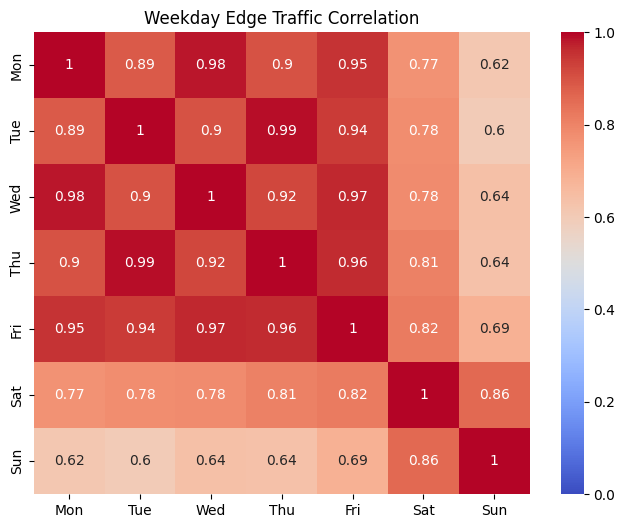

: 

In [ ]:
# Build separate graphs per weekday and extract weight vectors
import numpy as np
weekdays_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
days_data = {d: [] for d in range(7)}

edges = sorted(list(G.edges()))

for u, v in edges:
    edge_data = G[u][v].get('weekdays', {})
    for d in range(7):
        days_data[d].append(edge_data.get(d, 0))

df_days = pd.DataFrame(days_data)
df_days.columns = [weekdays_map[d] for d in range(7)]

# Correlation Matrix Across Weekdays
corr = df_days.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Weekday Edge Traffic Correlation")
plt.show()
